In [151]:
# Importing necessaries libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings
warnings.filterwarnings('ignore')

# preprocessing libraries
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix

# statistical libraries
from scipy import stats
from scipy.stats import zscore, skew

# set style for better visualisations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


In [152]:
data= 'cleaned_loan_dataset.csv'

In [153]:
df= pd.read_csv(data)

In [154]:
df.head(5)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [155]:
'debt_to_income_ratio','loan_amount','interest_rate', 'credit_score','annual_income'

('debt_to_income_ratio',
 'loan_amount',
 'interest_rate',
 'credit_score',
 'annual_income')

In [156]:
numerical_col=df.select_dtypes(include=[np.number]).columns
numerical_col

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back'],
      dtype='object')

In [157]:
# create a copy for preprocessing 
data= df.copy()

numerical= data[numerical_col]

# 1. checking for missing values (EDA showed no missing values)
print("\n1.  Missing Values:")
missing_values = data.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No missing values found (as expected from EDA)")

#2. check for duplicates
print("\n2. Duplicate Rows:")
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f'Percentage of duplicates: {(duplicates/len(data))* 100:.2sf}%')


# 3. Check skewness for variables identified in EDA as right-skewed
print("\n3. Skewness Analysis (EDA identified right-skewed variables):")    
skewed_vars = ['debt_to_income_ratio','loan_amount','interest_rate', 'credit_score','annual_income']
for var in skewed_vars:
    if var in data.columns:
        skewness = data[var].skew()
        print(f"{var}: skewness = {skewness:.3f} ({'right-skewed' if skewness > 0.5 else 'approximately normal'})")







1.  Missing Values:
No missing values found (as expected from EDA)

2. Duplicate Rows:
Number of duplicate rows: 0

3. Skewness Analysis (EDA identified right-skewed variables):
debt_to_income_ratio: skewness = 1.407 (right-skewed)
loan_amount: skewness = 0.207 (approximately normal)
interest_rate: skewness = 0.050 (approximately normal)
credit_score: skewness = -0.167 (approximately normal)
annual_income: skewness = 1.720 (right-skewed)


## Log-transform skewed variables as recommended by EDA

In [158]:
# Log-transform skewed variables as recommended by EDA
print("=== LOG-TRANSFORMING SKEWED VARIABLES ===")
print("EDA identified these variables as right-skewed and recommended log transformation:")

# Variables to log-transform based on EDA findings
skewed_vars = ['debt_to_income_ratio','loan_amount','interest_rate', 'credit_score','annual_income']

for var in skewed_vars:
    if var in data.columns:
        # Check if variable has zero or negative values
        min_val = data[var].min()
        if min_val <= 0:
            # Use log1p for variables with zeros
            data[f'{var}_log'] = np.log1p(data[var])
            print(f"✓ {var}: Applied log1p transformation (had {min_val:.3f} minimum value)")
        else:
            # Use log for positive values only
            data[f'{var}_log'] = np.log1p(data[var])
            print(f"✓ {var}: Applied log transformation")
        
        # Check skewness before and after
        original_skew = skew(data[var])
        transformed_skew = skew(data[f'{var}_log'])
        print(f"  Original skewness: {original_skew:.3f} → Transformed skewness: {transformed_skew:.3f}")

print(f"\nDataset shape after log transformation: {data.shape}")
print("New log-transformed columns:", [col for col in data.columns if '_log' in col])

=== LOG-TRANSFORMING SKEWED VARIABLES ===
EDA identified these variables as right-skewed and recommended log transformation:
✓ debt_to_income_ratio: Applied log transformation
  Original skewness: 1.407 → Transformed skewness: 1.219
✓ loan_amount: Applied log transformation
  Original skewness: 0.207 → Transformed skewness: -1.694
✓ interest_rate: Applied log transformation
  Original skewness: 0.050 → Transformed skewness: -0.452
✓ credit_score: Applied log transformation
  Original skewness: -0.167 → Transformed skewness: -0.427
✓ annual_income: Applied log transformation
  Original skewness: 1.720 → Transformed skewness: -0.342

Dataset shape after log transformation: (593994, 17)
New log-transformed columns: ['debt_to_income_ratio_log', 'loan_amount_log', 'interest_rate_log', 'credit_score_log', 'annual_income_log']


## Checking out for outliers found in EDA

In [159]:
numerical_col =df.select_dtypes(include=[np.number]).columns
numerical_col
for col in numerical_col:
    print(f'{col} = {df[col].skew():.3f}"  skewness value')




annual_income = 1.720"  skewness value
debt_to_income_ratio = 1.407"  skewness value
credit_score = -0.167"  skewness value
loan_amount = 0.207"  skewness value
interest_rate = 0.050"  skewness value
loan_paid_back = -1.491"  skewness value


In [160]:

# Outlier treatment based on EDA recommendations
print("=== OUTLIER TREATMENT (IQR-CAPPING METHOD) ===")

# Define numerical columns (excluding target)
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if 'Loan_Status' in numerical_cols:
    numerical_cols.remove('Loan_Status')

print(f"Treating outliers in {len(numerical_cols)} numerical features...")

# Apply IQR-capping method
outliers_capped = 0
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers before capping
    outliers_before = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
    
    if outliers_before > 0:
        # Cap outliers
        data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
        data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])
        outliers_capped += outliers_before
        print(f"✓ {col}: Capped {outliers_before} outliers")

print(f"\nTotal outliers capped: {outliers_capped}")
print(f"Dataset shape after outlier treatment: {data.shape}")

=== OUTLIER TREATMENT (IQR-CAPPING METHOD) ===
Treating outliers in 11 numerical features...
✓ annual_income: Capped 15917 outliers
✓ debt_to_income_ratio: Capped 17556 outliers
✓ credit_score: Capped 5901 outliers
✓ loan_amount: Capped 2902 outliers
✓ interest_rate: Capped 5136 outliers
✓ loan_paid_back: Capped 119500 outliers
✓ debt_to_income_ratio_log: Capped 13412 outliers
✓ loan_amount_log: Capped 37392 outliers
✓ interest_rate_log: Capped 8014 outliers
✓ credit_score_log: Capped 7462 outliers
✓ annual_income_log: Capped 2979 outliers

Total outliers capped: 236171
Dataset shape after outlier treatment: (593994, 17)


## Feature Engineering

In [161]:
data.head(5)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,debt_to_income_ratio_log,loan_amount_log,interest_rate_log,credit_score_log,annual_income_log
0,29367.99,0.084,736.0,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.080658,8.327875,2.685805,6.602588,10.287695
1,22108.02,0.166,636.0,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,1.0,0.153579,8.432528,2.633327,6.456770,10.003741
2,49566.20,0.097,694.0,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.092579,9.741330,2.375836,6.543912,10.811085
3,46858.25,0.065,536.5,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.062975,8.451797,2.839078,6.311989,10.754904
4,25496.70,0.053,665.0,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.051643,9.407996,2.416806,6.501290,10.146344


In [162]:
categorical_col= df.select_dtypes(include="object").columns
categorical_col

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

In [163]:
# encoding categorical variables
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le= LabelEncoder()
binary_col= ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
for col in binary_col:
    data[col] = le.fit_transform(data[col])
data.head()


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,debt_to_income_ratio_log,loan_amount_log,interest_rate_log,credit_score_log,annual_income_log
0,29367.99,0.084,736.0,2528.42,13.67,0,2,1,2,6,12,1.0,0.080658,8.327875,2.685805,6.602588,10.287695
1,22108.02,0.166,636.0,4593.10,12.92,1,1,2,0,2,17,1.0,0.153579,8.432528,2.633327,6.456770,10.003741
2,49566.20,0.097,694.0,17005.15,9.76,1,2,1,0,2,14,1.0,0.092579,9.741330,2.375836,6.543912,10.811085
3,46858.25,0.065,536.5,4682.48,16.10,0,2,1,0,2,25,1.0,0.062975,8.451797,2.839078,6.311989,10.754904
4,25496.70,0.053,665.0,12184.43,10.21,1,1,1,0,6,15,1.0,0.051643,9.407996,2.416806,6.501290,10.146344


## Scaled numeric data

In [164]:
numerical_col

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back'],
      dtype='object')

In [165]:
# let normalise numeric values to help algorithms like Logistic or SVM perform better.


scaler= StandardScaler()
data[numerical_col]= scaler.fit_transform(data[numerical_col])
data[numerical_col].std()

annual_income           1.000001
debt_to_income_ratio    1.000001
credit_score            1.000001
loan_amount             1.000001
interest_rate           1.000001
loan_paid_back          0.000000
dtype: float64

In [170]:
def correlation_with_target(data, target_col, figsize=(10,2)):
    """
    Plots a heatmap showing correlation of each numeric feature against target_col.
    Returns a series of correlations (sorted by absolute magnitude).
    """
    # Keep only numeric columns
    numeric_df = data.select_dtypes(include='number').copy()
    if target_col not in numeric_df.columns:
        raise ValueError(f"Target column '{target_col}' must be numeric and present in the dataframe.")

    # compute correlations of every numeric column with the target
    corrs = numeric_df.corrwith(numeric_df[target_col]).drop(target_col)

    corrs_df = corrs.to_frame(name='corr').T  # shape (1, n)

    plt.figure(figsize=figsize)
    sns.heatmap(
        corrs_df,
        annot=True,
        fmt=".3f",
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        cbar_kws={'orientation': 'vertical', 'shrink':0.7}
    )
    plt.xticks(rotation=45, ha='right')
    plt.yticks([0], [target_col], rotation=0)
    plt.title(f'Correlation of numeric features with {target_col}', fontsize=12)
    plt.tight_layout()
    plt.show()

    # return sorted correlations for downstream use
    return corrs.reindex(corrs.abs().sort_values(ascending=False).index)


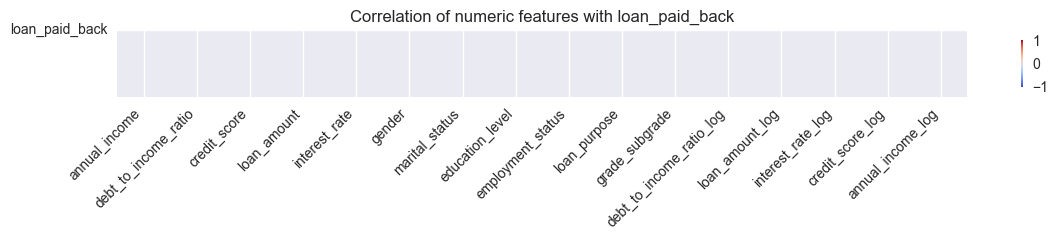

annual_income              NaN
debt_to_income_ratio       NaN
credit_score               NaN
loan_amount                NaN
interest_rate              NaN
gender                     NaN
marital_status             NaN
education_level            NaN
employment_status          NaN
loan_purpose               NaN
grade_subgrade             NaN
debt_to_income_ratio_log   NaN
loan_amount_log            NaN
interest_rate_log          NaN
credit_score_log           NaN
annual_income_log          NaN
dtype: float64


In [171]:
corr_series= correlation_with_target(data,'loan_paid_back', figsize=(12,2.5))
print(corr_series)